In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Motif binding score (see analysis code for calculation)
binding_data_dir = "binding_score_at_motifs"
background_binding_dir = f"{binding_data_dir}/background_binding_arrays"

# Human TF promoter-level chec-seq binding signal
sumprom_chec_glob = "sumproms/*.gz"

representative_regex_search = ["__*loc-prom__*family*__fl25__*.csv"]

## Imports

In [3]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
from matplotlib.scale import SymmetricalLogTransform

## Sample Groups and Family Metadata

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}
exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

all_samples = set(sum(dbd_fam_dict.values(), []))

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

plotting_order_fam = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "HXD10", "SOX10"]

## Helper Functions

In [5]:
# Load one sample's representative motif scores and matched background scores
def load_sample(sample_name, regex_search):
    if len(regex_search) == 1:
        df_files = glob.glob(
            f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[0]}"
        )
    if len(regex_search) == 2:
        df_files = (
            glob.glob(f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[0]}")
            + glob.glob(f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[1]}")
        )
    if len(df_files) != 1:
        return None, None

    bg_files = glob.glob(
        f"{background_binding_dir}/{sample_name}__*__loc-prom__signal_bg__fl25*.npy"
    )
    if len(bg_files) != 1:
        return None, None

    df = pd.read_csv(df_files[0])
    z_bg = np.load(bg_files[0])[:, 1]
    return z_bg, df


# Keep samples with reproducible signal across sequencing runs
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff):
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]


# Compute percent of motifs with z-score above 3 for one sample
def pct_z_gt3_and_n(sample):
    df = df_dict_representative.get(sample)
    if df is None or "z_score_norm_f7" not in df:
        return None, None

    z = df["z_score_norm_f7"].to_numpy(dtype=float)
    valid = ~np.isnan(z)
    if not valid.any():
        return None, None

    pct = 100.0 * (z[valid] > 3).mean()
    n = len(df)
    return pct, n

## Data Loading

In [6]:
# Load signal summaries from the three sequencing runs
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)

cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
good_samples = sumprom.columns[sumprom.columns.isin(all_samples)].tolist()
good_samples.append("ATF4")

# Load representative motif tables and matched background arrays
bg_dict = {}
df_dict_representative = {}
for sample in good_samples:
    bg_dict[sample], df_dict_representative[sample] = load_sample(
        sample,
        regex_search=representative_regex_search,
    )

## Data Processing

In [7]:
# Compute percent bound and motif counts per plotted sample
pct_map = {}
n_map = {}
for fam in plotting_order_fam:
    for s in dbd_fam_dict.get(fam, []):
        pct, n = pct_z_gt3_and_n(s) if s in good_samples else (None, None)
        if pct is not None:
            pct_map[s] = pct
            n_map[s] = n

# Compute background percent bound and enrichment
bg_pct_map = {}
enrich_map = {}
for s, pct in pct_map.items():
    bg = bg_dict.get(s, None)
    if bg is None:
        continue
    bg = np.asarray(bg, dtype=float)
    valid = ~np.isnan(bg)
    if not valid.any():
        continue

    bg_pct = 100.0 * (bg[valid] > 3).mean()
    bg_pct_map[s] = bg_pct

    if bg_pct <= 0:
        enrich = np.nan
    else:
        enrich = np.log2(pct / bg_pct)

    enrich_map[s] = enrich

# Build family-ordered sample positions with gaps between families
spacing = 2.0
gap_between = 2.0

samples = []
x_positions = []
fam_ranges = []
family_n_to_plot = {}
x_current = 0.0
idx = 0

for fam in plotting_order_fam:
    fam_samples = [s for s in dbd_fam_dict.get(fam, []) if s in pct_map]
    if not fam_samples:
        continue

    fam_samples.sort(key=lambda s: pct_map[s], reverse=True)

    fam_ns = [n_map[s] for s in fam_samples]
    n0 = fam_ns[0]
    if any(n != n0 for n in fam_ns[1:]):
        discrep = sorted(set(fam_ns))
        print(
            f"[DISCREPANCY] Family {fam}: motif counts differ across plotted samples: {discrep}. "
            f"Using n={n0} from first plotted sample ({fam_samples[0]})."
        )
    family_n_to_plot[fam] = n0

    start = idx
    for s in fam_samples:
        samples.append(s)
        x_positions.append(x_current)
        x_current += spacing
        idx += 1
    end = idx - 1
    fam_ranges.append((fam, start, end))

    x_current += gap_between

x = np.array(x_positions)
vals = np.array([pct_map[s] for s in samples])


## Plotting

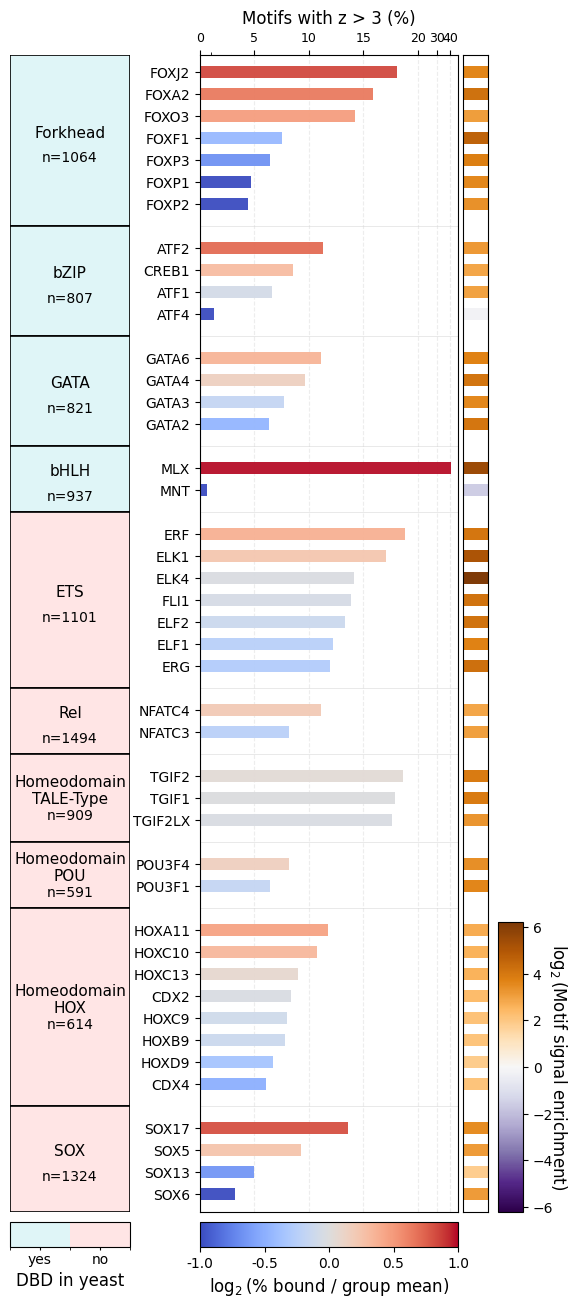

In [8]:
# Plot 3C: family-grouped horizontal bars colored by relative percent bound
samples_v = []
vals_v = []
enrich_v = []
ypos_v = []
fam_ranges_v = []
exists_v = {}
family_n_v = {}
name_v = {}

idx0 = 0
for fam, start, end in fam_ranges:
    fam_idx = list(range(start, end + 1))
    fam_idx_sorted = sorted(fam_idx, key=lambda i: vals[i], reverse=True)

    pos_slice = np.array(x[start:end + 1], dtype=float)
    pos_slice = np.sort(pos_slice)

    samples_v.extend([samples[i] for i in fam_idx_sorted])
    vals_v.extend([vals[i] for i in fam_idx_sorted])
    enrich_v.extend([enrich_map.get(samples[i], np.nan) for i in fam_idx_sorted])
    ypos_v.extend(list(pos_slice))

    fam_ranges_v.append((fam, idx0, idx0 + len(fam_idx_sorted) - 1))
    idx0 += len(fam_idx_sorted)

    exists_v[fam] = exists_in_yeast.get(fam, "no")
    family_n_v[fam] = family_n_to_plot[fam]
    name_v[fam] = family_name.get(fam, str(fam))

samples_v = list(samples_v)
vals_v = np.array(vals_v, dtype=float)
enrich_v = np.array(enrich_v, dtype=float)
ypos_v = np.array(ypos_v, dtype=float)

family_mean = {fam: vals_v[s:e + 1].mean() for fam, s, e in fam_ranges_v}

eps = 1e-9
log2_rel_v = np.empty_like(vals_v, dtype=float)
for fam, s, e in fam_ranges_v:
    m = family_mean[fam]
    frac = (vals_v[s:e + 1] + eps) / (m + eps)
    log2_rel_v[s:e + 1] = np.log2(frac)

cmap = plt.cm.coolwarm
norm = mpl.colors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)
colors_v = cmap(norm(log2_rel_v))

yeast_no_color = "#FFE5E5"
yeast_yes_color = "#DFF5F7"

fig, ax = plt.subplots(figsize=(5, 14))

bar_h = 1.1
ax.barh(ypos_v, vals_v, height=bar_h, alpha=0.95, color=colors_v)

linethresh = 20
xmax = 47
ax.set_xlim(0, xmax)
ax.set_xscale("symlog", base=100, linthresh=linethresh)

xticks = list(range(0, linethresh + 1, 5)) + list(range(linethresh + 10, xmax + 1, 10))
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=9)
ax.set_xlabel("Motifs with z > 3 (%)", labelpad=6, fontsize=12)

ax.set_axisbelow(True)
ax.grid(axis="x", which="major", color="lightgray", linestyle="--", linewidth=0.8, alpha=0.4)

ax.set_yticks(ypos_v)
ax.set_yticklabels(["ERF" if s == "ERF1" else s for s in samples_v],fontsize=10)

ax.invert_yaxis()

for (_, _, end_idx), (_, start_next, _) in zip(fam_ranges_v[:-1], fam_ranges_v[1:]):
    by = 0.5 * (ypos_v[end_idx] + ypos_v[start_next])
    ax.axhline(by, color="lightgray", linewidth=0.5, alpha=0.7, zorder=0)

ax.margins(y=0.01)

plt.tight_layout(rect=[0.15, 0.10, 0.86, 0.98])
pos = ax.get_position()

enr_cmap = plt.cm.PuOr_r
vmax = np.nanmax(enrich_v)
enr_norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)
enr_colors = enr_cmap(enr_norm(enrich_v))

strip_gap = 0.01
strip_w = 0.05
ax_enr = fig.add_axes([pos.x1 + strip_gap, pos.y0, strip_w, pos.height * 1.0], sharey=ax)
ax_enr.set_xlim(0, 1)
ax_enr.tick_params(axis="y", left=False, labelleft=False)
ax_enr.set_xticks([])
ax_enr.barh(ypos_v, np.ones_like(ypos_v), height=bar_h, color=enr_colors, edgecolor="none")

sm_enr = mpl.cm.ScalarMappable(norm=enr_norm, cmap=enr_cmap)
sm_enr.set_array([])

cb_w = 0.05
cb_pad = 0.02
cax_enr = fig.add_axes([pos.x1 + strip_gap + strip_w + cb_pad, pos.y0, cb_w, pos.height * 0.25])
cb_enr = fig.colorbar(sm_enr, cax=cax_enr, orientation="vertical")
cb_enr.ax.tick_params(labelsize=10)
cb_enr.set_label(r"$\log_2(\mathrm{Motif\ signal\ enrichment})$", fontsize=12, rotation=270, labelpad=11)

strip_pad = 0.14
strip_w = 0.24

ax_fam = fig.add_axes([pos.x0 - strip_w - strip_pad, pos.y0, strip_w, pos.height], sharey=ax)
ax_fam.set_xlim(0, 1)
ax_fam.axis("off")

ylim = ax.get_ylim()
ymin_lim, ymax_lim = sorted(ylim)

edges_y = {}
for i, (fam, s, e) in enumerate(fam_ranges_v):
    if i == 0:
        top_edge = ymin_lim
    else:
        _, ps, pe = fam_ranges_v[i - 1]
        top_edge = 0.5 * (ypos_v[pe] + ypos_v[s])

    if i == len(fam_ranges_v) - 1:
        bot_edge = ymax_lim
    else:
        _, ns, _ = fam_ranges_v[i + 1]
        bot_edge = 0.5 * (ypos_v[e] + ypos_v[ns])

    edges_y[fam] = (top_edge, bot_edge)

for fam, s, e in fam_ranges_v:
    y0, y1 = edges_y[fam]
    yy0, yy1 = (min(y0, y1), max(y0, y1))

    flag = str(exists_v.get(fam, "no")).strip().lower()
    fc = yeast_yes_color if flag == "yes" else yeast_no_color

    ax_fam.add_patch(
        mpatches.Rectangle(
            (0, yy0), 1, yy1 - yy0,
            transform=ax_fam.transData,
            facecolor=fc, edgecolor="black", lw=1.2
        )
    )

    yc = 0.5 * (yy0 + yy1)

    ax_fam.text(0.5, yc - 0.7, name_v.get(fam, str(fam)),
                transform=ax_fam.transData, ha="center", va="center", fontsize=11)
    ax_fam.text(0.5, yc + 1.6, f"n={family_n_v[fam]}",
                transform=ax_fam.transData, ha="center", va="center", fontsize=10)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

yeast_cmap = mpl.colors.ListedColormap([yeast_yes_color, yeast_no_color])
yeast_norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5], yeast_cmap.N)
sm_yeast = mpl.cm.ScalarMappable(norm=yeast_norm, cmap=yeast_cmap)
sm_yeast.set_array([])

pos_fam = ax_fam.get_position()

cb_pad = 0.025
cb_h = 0.018

cax_log2 = fig.add_axes([pos.x0, pos.y0 - cb_pad, pos.width, cb_h])
cb1 = fig.colorbar(sm, cax=cax_log2, orientation="horizontal")
cb1.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cb1.ax.tick_params(labelsize=10)
cb1.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
cb1.set_label(r"$\log_2$(% bound / group mean)", labelpad=4, fontsize=12)

cax_yeast = fig.add_axes([pos_fam.x0, pos.y0 - cb_pad, pos_fam.width, cb_h])
cb2 = fig.colorbar(sm_yeast, cax=cax_yeast, orientation="horizontal")
cb2.set_ticks([0, 1])
cb2.set_ticklabels(["yes", "no"])
cb2.ax.tick_params(labelsize=10, length=2, pad=2)
cb2.set_label("DBD in yeast", labelpad=4, fontsize=12)

plt.show()

/tmp/ipykernel_3733695/100295350.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


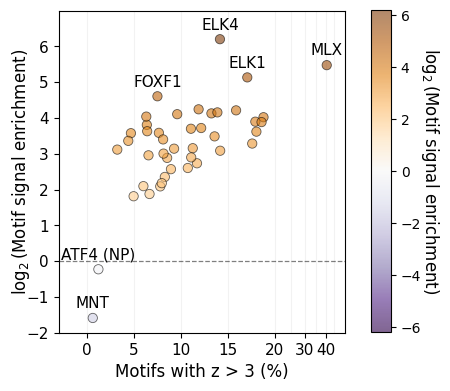

In [9]:
# Plot 3E: scatter of percent bound versus motif signal enrichment
common_keys = sorted(set(pct_map) & set(enrich_map))
x_vals = np.array([pct_map[k] for k in common_keys], dtype=float)
y_vals = np.array([enrich_map[k] for k in common_keys], dtype=float)

y_arr = y_vals
top_idx = np.argsort(y_arr)[-4:]
bot_idx = np.argsort(y_arr)[:2]
label_idx = list(top_idx) + list(bot_idx)

enr_cmap = plt.cm.PuOr_r
vmax = np.nanmax(np.abs(y_vals))
enr_norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

fig, ax = plt.subplots(figsize=(3.65, 4))

sc = ax.scatter(
    x_vals,
    y_vals,
    c=y_vals,
    cmap=enr_cmap,
    norm=enr_norm,
    edgecolor="black",
    linewidth=0.6,
    s=45,
    alpha=0.6
)

ax.set_xlabel("Motifs with z > 3 (%)", fontsize=12)
ax.set_ylabel(r"$\log_2(\mathrm{Motif\ signal\ enrichment})$", fontsize=12, labelpad=-4)

ax.set_ylim(-2, 6.99)

ax.set_xscale("symlog", linthresh=20)
ax.set_xticks([0, 5, 10, 15, 20, 30, 40])
ax.set_xlim(-3, 52)
ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))

ax.axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=0.9)

for x in np.arange(0, 50, 5):
    ax.axvline(x, color="0.5", alpha=0.1, linewidth=0.8, zorder=0)

for i in label_idx:
    label = common_keys[i]
    if label == "ATF4":
        label = "ATF4 (NP)"
    ax.annotate(
        label,
        (x_vals[i], y_vals[i]),
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=11,
        ha="center",
        va="bottom"
    )

ax.tick_params(axis="both", labelsize=11)

pos = ax.get_position()

cax = fig.add_axes([
    pos.x1 + 0.13,
    pos.y0 + 0.05,
    0.055,
    pos.height + 0.035
])

cb = fig.colorbar(sc, cax=cax)
cb.ax.tick_params(labelsize=10)
cb.set_label(r"$\log_2(\mathrm{Motif\ signal\ enrichment})$", fontsize=12, rotation=270, labelpad=14)

plt.tight_layout()
plt.show()

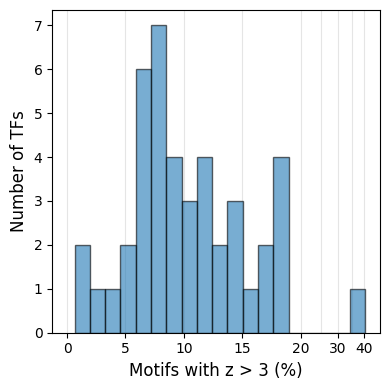

In [10]:
# Plot 3D: histogram of percent bound on a symlog x-axis
fig, ax = plt.subplots(figsize=(4, 4))

linthresh = 20
base = 10
linscale = 1

T = SymmetricalLogTransform(base=base, linthresh=linthresh, linscale=linscale)
Ti = T.inverted()

vals = np.asarray(vals)
vals_t = T.transform_non_affine(vals)

bin_edges_t = np.linspace(vals_t.min(), vals_t.max(), 20)
bin_edges = Ti.transform_non_affine(bin_edges_t)
bin_edges[-1] = np.nextafter(bin_edges[-1], bin_edges[-1] + 1)

for x in np.arange(0, 45, 5):
    ax.axvline(x, color="0.5", alpha=0.2, linewidth=0.8, zorder=0)

ax.hist(vals, bins=bin_edges, edgecolor="black", alpha=0.6, zorder=2)

ax.set_xlabel("Motifs with z > 3 (%)", fontsize=12)
ax.set_ylabel("Number of TFs", fontsize=12)

ax.set_xscale("symlog", linthresh=linthresh, base=base, linscale=linscale)
ax.set_xticks([0, 5, 10, 15, 20, 30, 40])
ax.set_xticklabels(["0", "5", "10", "15", "20", "30", "40"])
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

plt.tight_layout()
plt.show()